In [1]:
import pandas as pd
from tqdm import tqdm 
import scanpy as sc
import sys
import os 
import logging 
from omegaconf import OmegaConf, DictConfig
from hydra import initialize, compose
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from pathlib import Path 
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn.functional as F

from labcompass.constants import DataFields
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn
)

logger = logging.getLogger(__name__)

In [2]:
def uncertainty_quantification(
    forward_model,
    base_cfg,
    annotation, 
    paths, 
    constraints,
    X_candidates, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column):
    
    protocol_columns = base_cfg["annotation"]["protocol_columns"]

    ct_le = LabelEncoder()
    ct_values = target_prediction_model.train_data.adata.obs[cell_type_column].values
    ct_le.fit(ct_values)
    classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 
    print(classes)

    # Take cell type index 
    cell_type_index = classes.index(target_cell_types)
    ct_safe_string = target_cell_types.replace("/", ":") # cell type dir

    X_candidates = torch.from_numpy(X_candidates).float().to("cuda")
    X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
    condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}

    forward_out = forward_model.predict(
        batch_dict,
        no_grad=True,
        fix_noise=False,
        num_time_steps=100
    )
    
    y_pred = forward_out["target_prediction_data"][cell_type_column].view(X_candidates_add.shape[0],
                                                                     n_populations,
                                                                     -1,
                                                                     len(classes))  
    y_pred_softmax = F.softmax(y_pred, dim=-1)

    # Take the mean proportions 
    y_pred_mean = y_pred.mean(2)  # no_candidates x no_populations x no_cell_types 
    y_pred_softmax = y_pred_softmax.mean(2)  # no_candidates x no_populations x no_cell_types 

    # Collect cell type of interest 
    y_pred_ct_std = y_pred_softmax[..., cell_type_index].std(1).detach().cpu().numpy()  # standard deviation prob cell type of interest 
    # Calculate loss
    y_target_ct = np.zeros((1, len(classes)))
    y_target_ct[:, cell_type_index] = 1.0
    y_target_ct = torch.from_numpy(y_target_ct)
    y_target_ct = y_target_ct.unsqueeze(0).to("cuda")  # 1 x 1 x no_cell_types
    
    logger.info("Compute loss function")
    loss_fn = lambda pred, target: -torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
    with torch.no_grad():
        loss = loss_fn(y_pred_mean, y_target_ct)  # no_candidates x no_populations

    loss_std = loss.std(1).detach().cpu().numpy()  # no_candidates
    return y_pred_softmax.mean(1), loss_std

## Read protocols 

In [3]:
adata = sc.read_h5ad("../../../../../../project_folder/output/loops/data/loop2p5/replicate/adata_500k.h5ad")

In [4]:
protocol_cols = ['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
                 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
                 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']

adata_protocols = adata.obs.loc[:, protocol_cols]

In [5]:
adata_protocols = np.log1p(adata_protocols.drop_duplicates().astype(float))

In [6]:
experiment_number = adata[adata_protocols.index].obs.experiment_number

In [7]:
base_config_path = "../../../../../../inverse/loss_guidance/config/"
base_config_name = "run_inverse"
annotation = "bloodplus"
paths = "loop1"
constraints = "default_all_cols"
target_cell_types = "EryPro"
n_noise_samples = 5000
n_populations = 10
cell_type_column = "cell_type" 

# Initialize paths 
with initialize(config_path=base_config_path, version_base=None):
    base_cfg = compose(
        config_name=base_config_name,
        overrides=[f"paths={paths}", 
                   f"annotation={annotation}", 
                   f"constraints={constraints}"])
base_cfg.loss.cell_type_column = cell_type_column

# Collect the forward model
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

In [8]:
pred, _ = uncertainty_quantification(
    forward_model, 
    base_cfg,
    annotation, 
    paths, 
    constraints,
    adata_protocols.values, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column)

['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP', 'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro', 'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP', 'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP', 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']


In [9]:
pred = pred.detach().cpu().numpy()

In [10]:
ce_matrix = (-(pred[:, None] * np.log(pred[None, :]))).sum(-1)

np.fill_diagonal(ce_matrix, np.inf)      

min_ce = ce_matrix.min(-1)

<Axes: ylabel='Density'>

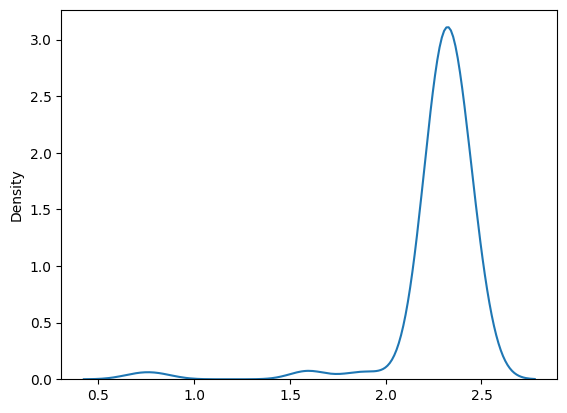

In [11]:
sns.kdeplot(min_ce)

In [21]:
min_ce[experiment_number=="241"]

array([2.3355324], dtype=float32)

In [22]:
min_ce[experiment_number=="242"]

array([2.3066163], dtype=float32)

In [23]:
min_ce[experiment_number=="249"]

array([2.3654299], dtype=float32)

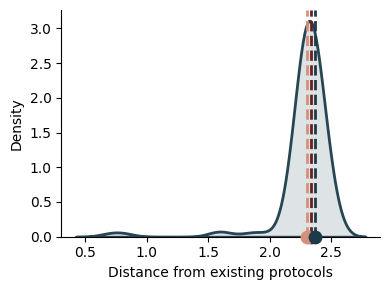

In [30]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.kdeplot(min_ce, color="#264653", fill=True, alpha=0.15, linewidth=2, ax=ax)

# Values to highlight
highlight_vals = {
    "241": (2.3355324, "#6B1F1F"),
    "242": (2.3066163, "#D4917A"),
    "249": (2.3654299, "#1C3A4A"),
}

for label, (val, color) in highlight_vals.items():
    ax.axvline(val, color=color, linestyle="--", linewidth=2, zorder=5)
    ax.scatter(val, 0, color=color, s=80, zorder=6, clip_on=False)
    # ax.annotate(
    #     label,
    #     xy=(val, ax.get_ylim()[1] * 0.05),
    #     xytext=(val, ax.get_ylim()[1] * 0.9),
    #     rotation=90,
    #     va="top",
    #     ha="right",
    #     fontsize=10,
    #     color=color,
    #     fontweight="bold",
    # )

ax.set_xlabel("Distance from existing protocols")
ax.set_ylabel("Density")
# ax.set_title("Distance to existing protocols, by experiment")
sns.despine()
plt.tight_layout()
plt.savefig("distance_kde_highlighted_erypro.svg", bbox_inches="tight")
plt.show()